### Preamble

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from traffic_scheduling.network.drawing import draw_vehicles, draw_road
from traffic_scheduling.network.basics import generate_grid_network
from traffic_scheduling.motion import generate_trajectories
import os

# make sure the figures directory exists
os.makedirs('figures', exist_ok=True)

In [ ]:
%load_ext autoreload
%autoreload 2

/home/jeroen/repos/traffic-scheduling/network


# Figures for presentation

## Network model

In [ ]:
from traffic_scheduling.network.basics import generate_instance, uniform

name = "net3x2"
F = uniform(0, 1)
instance = generate_instance(F, n=[20]*7, net_m=4, net_n=3)
G = instance.G
routes = instance.routes
vehicle_l = 1.2
vehicle_w = 0.5

In [258]:
def draw_net(positions, step):
    fig = instance.draw_road(road_width=1);
    ax = fig.get_axes()[0]
    draw_vehicles(G, routes, positions, vehicle_l, vehicle_w, ax)
    fig.savefig(f'figures/network-{step}.pdf', bbox_inches='tight', pad_inches=0)
    plt.close()

positions = {
    (0,0): 6, (0,1): 23,
    (1,0): 12, (1,1): 23,
    (2,0): 3, (2,1): 8,
    (3,0): 3, (3,1): 16,
    (4,0): 8, (4,1): 13, (4,2): 24,
    (5,0): 20, (5,1): 34, (5,2): 34,
    (6,0): 8, (6,1): 30,
}

draw_net(positions, 1)
# increase all positions, manually prevent collisions
positions = { key: value + 1 for key, value in positions.items() }
draw_net(positions, 2);
positions = { key: value + 1 for key, value in positions.items() }
draw_net(positions, 3);
positions = { key: value + 1 for key, value in positions.items() }
draw_net(positions, 4);

## Crossing time

In [43]:
G, routes = generate_grid_network(xdist=[4, 4], ydist=[10, 10])

vehicle_l, vehicle_w = 2.4, 2

cross_time = 15

r = [[0], []]
y = {
    (0,0, (1,1)): cross_time,
    (0,0, (1,2)): 25,
}

dt = 0.25
params = dict(vmax=1, umax=0.5, l=1.20, dt=dt)
trajectories = generate_trajectories(G, routes, r, y, vehicle_w, params)
t0, positions = trajectories[0][0]
times = [t0 + i*dt for i in range(len(positions))]

SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 926.5000054
46851 simplex iterations


In [44]:
# helper function for horizontal line spanning both axes
def draw_fig_hline(x_start, x_end, y, fig, ax_left, ax_right):
    _, y = ax_left.transData.transform((x_start, y))
    _, y_fig = fig.transFigure.inverted().transform((x_start, y))

    fig.canvas.draw() # update layout/transforms
    x_start, _ = ax_left.transData.transform((x_start, 0))
    x_start, _ = fig.transFigure.inverted().transform((x_start, 0))
    x_end, _ = ax_right.transData.transform((x_end, 0))
    x_end, _ = fig.transFigure.inverted().transform((x_end, 0))

    # vertical line accross axes
    fig.lines.append(plt.Line2D(
        [x_start, x_end],  # from left plot to right
        [y_fig, y_fig],
        transform=fig.transFigure,
        color='grey', linestyle='--', linewidth=1
    ))

In [58]:
step = 1
def draw_state(time, block=0, follower=False, crosser=False, silent=False):
    global step # for automatic figure numbering
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, 
        sharey=True, 
        figsize=(8, 4), 
        gridspec_kw={'width_ratios': [3, 1]}  # left 3x wider than right
    )
    # draw trajectory on the left
    ax_left.plot(times, positions, linewidth=1)
    # draw road with small cross road on the right
    draw_road(G, road_width=vehicle_w, ax=ax_right);

    def interpolate(target_time):
        # HACK: ...not really interpolation
        ti = 0
        while times[ti] < target_time:
            ti += 1
        return positions[ti]
    pos = interpolate(time)
    cross_pos = interpolate(cross_time)

    draw_vehicles(G, routes, { (0,0): pos }, vehicle_l, vehicle_w / 2, ax_right)
    if follower:
        draw_vehicles(G, routes, { (0,0): pos - vehicle_l - 0.1 }, vehicle_l, vehicle_w / 2, ax_right, colors={(0,0): 'grey'})
    if crosser:
        draw_vehicles(G, routes, { (1,0): 4 - vehicle_l / 2}, vehicle_l, vehicle_w / 2, ax_right, colors={(1,0): 'grey'})
    draw_fig_hline(time + 0.3, 3.5, pos + 0.01, fig, ax_left, ax_right)

    time_block_height = 0.4
    if block >= 1:
        ax_left.vlines(x=cross_time, ymin=0, ymax=cross_pos, linewidth=1, linestyle='--', color='grey', zorder=1)
    if block >= 2:
        ax_left.vlines(x=cross_time + vehicle_l, ymin=0, ymax=cross_pos+vehicle_l, linewidth=1, linestyle='--', color='grey', zorder=1)
    # draw time "block" a little above the x-axis, with vertical lines to trajectory
    if block >= 3:
        ax_left.vlines(x=cross_time + vehicle_l + vehicle_w, ymin=0, ymax=cross_pos+vehicle_l+vehicle_w, linewidth=1, linestyle='--', color='grey')
    # draw little arrow for switch-over time
    if block >= 4:
        rect = Rectangle((cross_time, 0), angle=0, width=vehicle_l, height=time_block_height, color='grey', zorder=2)
        ax_left.add_patch(rect)
        ax_width_inch = ax_left.get_window_extent().transformed(fig.dpi_scale_trans.inverted()).width
        q_kwargs = { 'width': 1 / 72 / ax_width_inch, 'headwidth': 6, 'headlength':10, 'headaxislength': 9, 'angles': 'xy', 'scale_units': 'x', 'scale': 1 }
        ax_left.quiver(cross_time + vehicle_l, time_block_height / 2, vehicle_w, 0, color='grey', **q_kwargs)

    # little red dot on trajectory
    ax_left.plot(time, pos, 'ro', markersize=3)

    # figure styling
    ax_left.set_xlabel('time'); ax_left.set_ylabel('position')
    ax_left.xaxis.set_major_locator(MaxNLocator(steps=[5], integer=True))
    ax_left.yaxis.set_visible(False)
    # hide all spines except the bottom (x-axis)
    for spine in ['top', 'right', 'left']: ax_left.spines[spine].set_visible(False)
    ax_right.axis('off')

    fig.savefig(f'figures/crossing-{step}.pdf');
    if silent: plt.close()
    step += 1

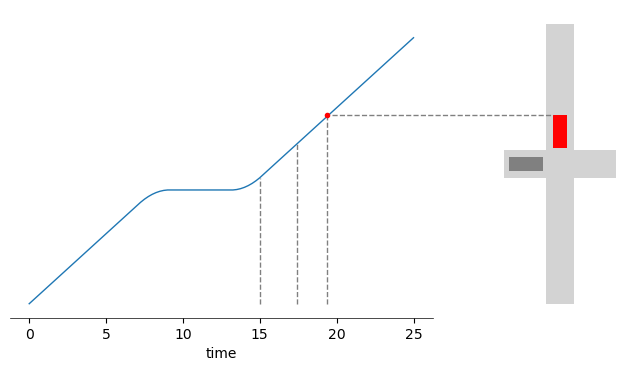

In [62]:
step = 1
draw_state(3, block=False, silent=True)
draw_state(5, block=False, silent=True)
draw_state(7, block=False, silent=True)
draw_state(11, block=False, silent=True)
draw_state(15, block=1, silent=True)
draw_state(15 + 1, block=1, silent=True)
draw_state(15 + vehicle_l, block=2, silent=True)
draw_state(15 + vehicle_l, block=2, follower=True, silent=True)
draw_state(15 + vehicle_l + vehicle_w, block=3, silent=True)
draw_state(15 + vehicle_l + vehicle_w, block=3, crosser=True, silent=False)
draw_state(21, block=3, silent=True)
draw_state(21, block=4, silent=True)

## Crossing time scheduling

In [ ]:
from traffic_scheduling.single.basics import SingleInstance
instance = SingleInstance(
    arrivals=[[1, 2.4], [0.5, 2.9]]
)

Plot empty schedule.

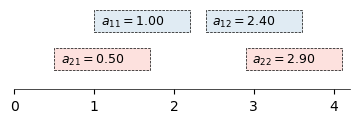

In [ ]:
from traffic_scheduling.single.mdp import SingleScheduleEnv
options = dict(one_based_indices=True, out='figures/empty-schedule.pdf')
env = SingleScheduleEnv(instance=instance, options=options)
env.reset()
env.render()

Draw a little single intersection to keep the visualization alive.

In [235]:
G, routes = generate_grid_network(xdist=[20, 5], ydist=[20, 10])
fig, ax = plt.subplots()
draw_road(G, road_width=vehicle_w, ax=ax);

positions = {
    (0,0): 12, #red
    (0,1): 5,
    (1,0): 10, #blue
    (1,1): 7,
} 
# N.B., for the sake of the presentation, suppose the horizontal route is "0",
# so we color it blue, such that it corresponds with the top row in the schedule
colors = { (0,0): 'red', (0,1): 'red', (1,0): 'blue', (1,1): 'blue' } 
draw_vehicles(G, routes, positions, vehicle_l, vehicle_w / 2, ax, colors=colors)

ax.axis('off')
fig.tight_layout()
fig.savefig('figures/initial-intersection.pdf')
plt.close()

Choose some route order, and draw the resulting schedule.

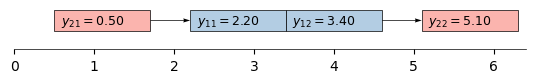

In [245]:
env.reset()
[env.step(r) for r in [1, 0, 0, 1]]
env.options['out'] = 'figures/complete-schedule.pdf'
env.options['block_text'] = True
env.options['arrow_text'] = False
env.render()

## Integer Programming

Draw some empty networks to illustrate m and n.

In [ ]:
from traffic_scheduling.network.basics import generate_grid_network
from traffic_scheduling.network.drawing import draw_road

def plot_network(m, n):
    G, _ = generate_grid_network(m, n, xdist=10, ydist=10)
    fig = draw_road(G, road_width=1)
    fig.savefig(f'figures/empty-network-{m}-{n}.pdf', bbox_inches='tight', pad_inches=0)
    plt.close()

In [267]:
plot_network(2, 2) 
plot_network(3, 2) 
plot_network(4, 3) 

## Cutting planes in single intersection

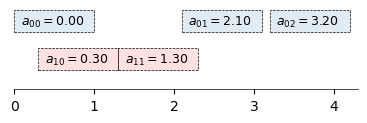

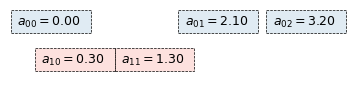

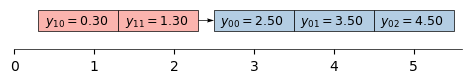

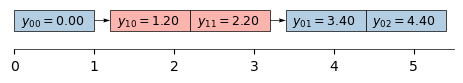

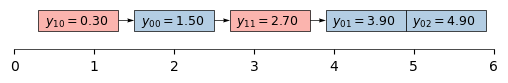

In [ ]:
from traffic_scheduling.single.basics import SingleInstance
from traffic_scheduling.single.mdp import SingleScheduleEnv
opts = dict(arrow_text=False)

s = SingleInstance(arrivals=[
    [0, 2.1, 3.2],
    [0.3, 1.3],
], rho=1, sigma=1.2)


env = SingleScheduleEnv(instance=s, options=opts)
env.reset()
env.options['out'] = 'figures/cut-1.pdf'
env.render()

env.reset()
env.options['out'] = 'figures/cut-1-no-axis.pdf'
env.options['no_axis'] = True
env.render()
env.options['no_axis'] = False

# this one is optimal
# s.solve()
# s.opt.visualize(**opts)
env.reset()
[env.step(r) for r in [1, 1, 0, 0, 0]]
env.options['out'] = 'figures/cut-2.pdf'
env.render()

env.reset()
[env.step(r) for r in [0, 1, 1, 0, 0]]
env.options['out'] = 'figures/cut-3.pdf'
env.render()

env.reset()
[env.step(r) for r in [1, 0, 1, 0, 0]]
env.options['out'] = 'figures/cut-4.pdf'
env.render()

## Constructive Heuristics

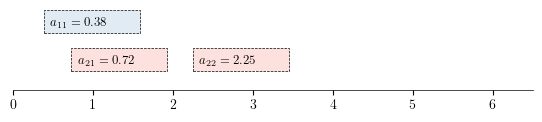

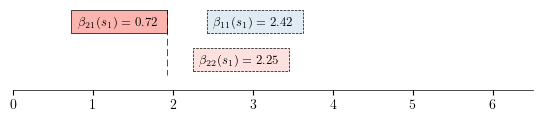

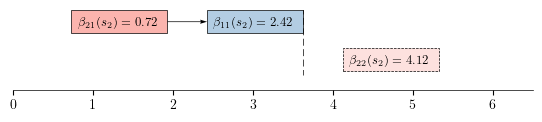

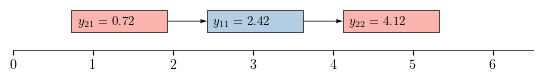

In [ ]:
from traffic_scheduling.single.basics import generate_simple_instance
from traffic_scheduling.single.mdp import SingleScheduleEnv
import numpy as np

# some instance
s = generate_simple_instance(n=[1,2])

# create the MDP ("environment")
options = {
    'collapse_current': True,
    'fixed_end': 6.5,
    'tex': True,
    'one_based_indices': True,
    'arrow_text': False,
    'out': 'figures/episode{t}.pdf',
}
env = SingleScheduleEnv(instance=s, options=options)
obs, info = env.reset()
env.action_space.seed(12) # to keep the same example once we like it
env.render()

done = False
while not done:
    # mask = valid actions = routes with unscheduled vehicles
    mask = (~obs['done']).astype(np.int8)
    action = env.action_space.sample(mask)
    obs, reward, done, truncated, info = env.step(action)
    env.render()

## Threshold heuristic

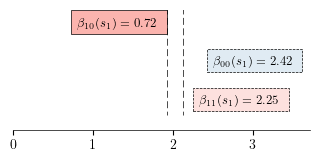

In [ ]:
s = SingleInstance(arrivals=[
    [0.38],
    [0.72, 2.25],
])

from traffic_scheduling.single.mdp import SingleScheduleEnv

env = SingleScheduleEnv(instance=s)
env.reset()
env.step(1)
env.options['extra_time_lines'] = [0.72 + 1.2 + 0.2]
env.options['out'] = 'figures/threshold-1.pdf'
env.options['collapse_current'] = False
env.render()

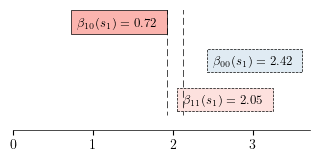

In [ ]:
s = SingleInstance(arrivals=[
    [0.38],
    [0.72, 2.05],
])

from traffic_scheduling.single.mdp import SingleScheduleEnv

env = SingleScheduleEnv(instance=s)
env.reset()
env.step(1)
env.options['extra_time_lines'] = [0.72 + 1.2 + 0.2]
env.options['out'] = 'figures/threshold-2.pdf'
env.options['collapse_current'] = False
env.render()